# Laboratorio 4. Análisis de Datos Geoespaciales

**Avance: ejercicios 1 al 4**  
**Curso:** CC3084 - Data Science  
**Integrantes:** Ihan Marroquín - 23108 y Diego Patzán - 23525  
**Fecha:** 13 de agosto de 2026

Este cuaderno estudia cómo cambia la señal estimada de cianobacteria en los
lagos Atitlán y Amatitlán. La idea no es reemplazar una muestra de agua tomada
en campo, sino aprovechar las imágenes de Sentinel-2 para reconocer momentos y
zonas que merecen una revisión más cercana.

## Antes de comenzar

El cuaderno tiene dos modos. Con `EJECUTAR_COPERNICUS = False` se pueden revisar
las fechas, las áreas de estudio y la calidad preliminar sin abrir trabajos en
la nube. Cuando se cambie a `True`, Copernicus solicitará iniciar sesión en el
navegador y entonces se descargarán los resultados reales.

Este avance se entrega en modo de revisión para no inventar valores que todavía
no han sido generados por el servicio satelital.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

carpeta_actual = Path.cwd().resolve()
RAIZ = carpeta_actual.parent if carpeta_actual.name == "notebooks" else carpeta_actual
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.procesamiento_geoespacial import (
    LAGOS,
    CARPETA_DATOS,
    conectar,
    descargar_rasters_multitemporales,
    descargar_serie_temporal,
    graficar_evolucion,
    preparar_indices,
    resumir_picos,
)

EJECUTAR_COPERNICUS = False
DESCARGAR_RASTERS = True

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

print(f"Proyecto: {RAIZ}")
print("Modo:", "ejecución con Copernicus" if EJECUTAR_COPERNICUS else "revisión sin descargas")

Proyecto: C:\Users\VICTUS\Desktop\8vo Semestre\Data\Lab4\lab4
Modo: revisión sin descargas


## 1. Conexión con Sentinel-2

La conexión se realiza mediante openEO, el servicio de Copernicus que permite
pedir el procesamiento desde Python. El inicio de sesión es interactivo: la
contraseña nunca queda escrita en el notebook ni en el repositorio.

In [2]:
conexion = None

if EJECUTAR_COPERNICUS:
    conexion = conectar()
else:
    print("Conexión preparada. Cambie EJECUTAR_COPERNICUS a True para autenticar y ejecutar los trabajos.")

Conexión preparada. Cambie EJECUTAR_COPERNICUS a True para autenticar y ejecutar los trabajos.


## 2. Obtención de los datos necesarios

Se utilizan solamente las 11 fechas oficiales de cada lago. También se limita
la consulta a los rectángulos entregados en la guía, de modo que no se descargan
escenas completas de Guatemala. Dentro de cada área se retiran nubes, sombras y
terreno que no corresponde al agua.

In [3]:
resumen_lagos = pd.DataFrame(
    [
        {
            "Lago": nombre,
            "Oeste": datos["bbox"]["west"],
            "Este": datos["bbox"]["east"],
            "Sur": datos["bbox"]["south"],
            "Norte": datos["bbox"]["north"],
            "Fechas": len(datos["fechas"]),
        }
        for nombre, datos in LAGOS.items()
    ]
)

display(resumen_lagos)

,Lago,Oeste,Este,Sur,Norte,Fechas
0,Amatitlan,-90.638065,-90.512924,14.412347,14.493799,11
1,Atitlan,-91.326256,-91.071510,14.594800,14.750979,11


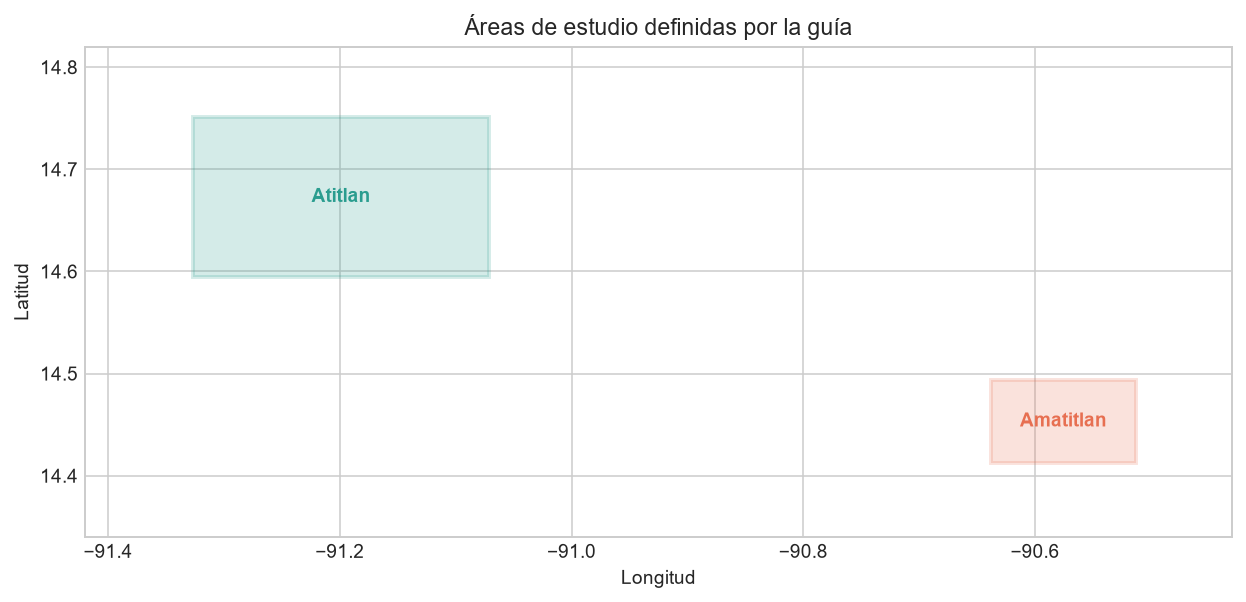

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.4), dpi=140)
colores = {"Atitlan": "#2a9d8f", "Amatitlan": "#e76f51"}

for nombre, datos in LAGOS.items():
    bbox = datos["bbox"]
    ancho = bbox["east"] - bbox["west"]
    alto = bbox["north"] - bbox["south"]
    rectangulo = plt.Rectangle(
        (bbox["west"], bbox["south"]), ancho, alto,
        facecolor=colores[nombre], edgecolor=colores[nombre], alpha=0.20, linewidth=2
    )
    ax.add_patch(rectangulo)
    ax.text(
        bbox["west"] + ancho / 2, bbox["south"] + alto / 2, nombre,
        ha="center", va="center", color=colores[nombre], fontweight="bold"
    )

ax.set_xlim(-91.42, -90.43)
ax.set_ylim(14.34, 14.82)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Áreas de estudio definidas por la guía")
fig.tight_layout()

ruta_areas = RAIZ / "reports" / "figures" / "areas_estudio.png"
ruta_areas.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ruta_areas, bbox_inches="tight")
plt.show()

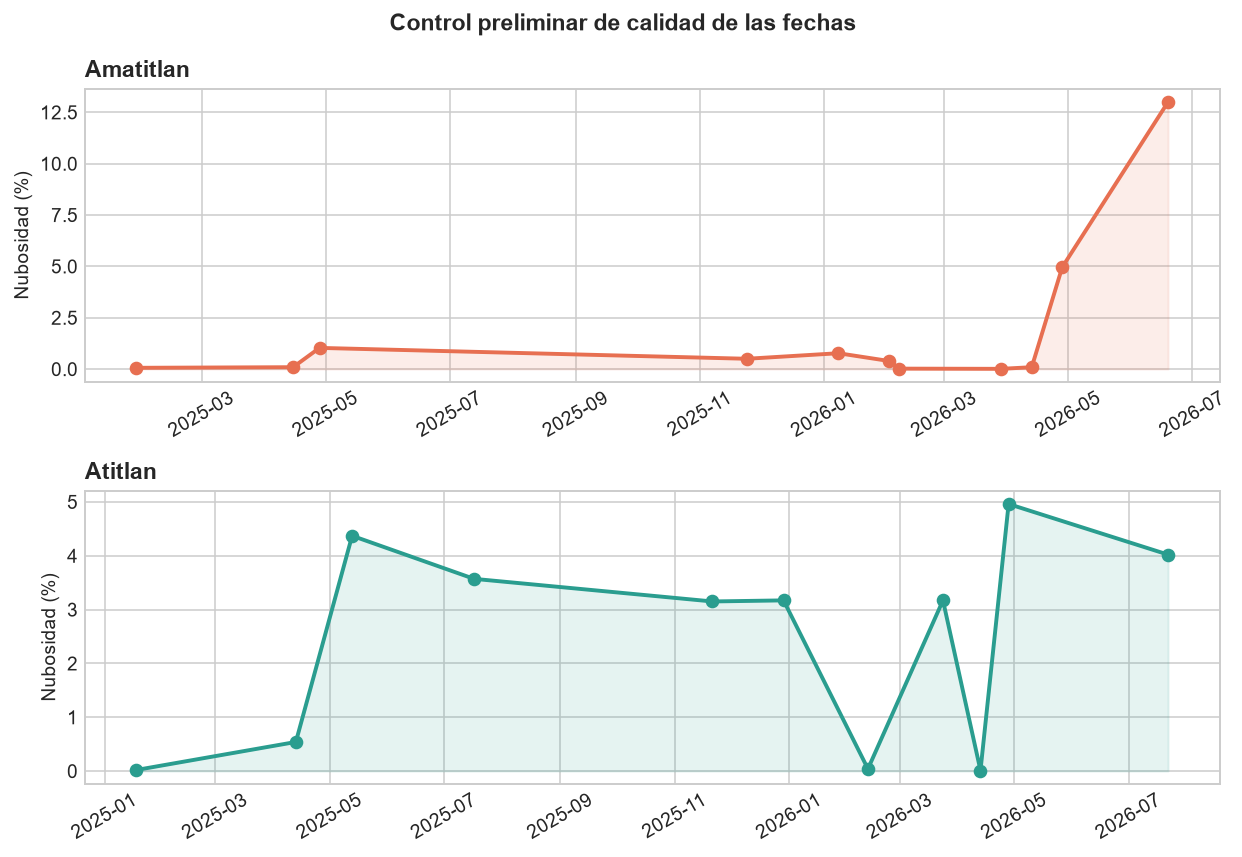

Atitlán se mantiene debajo de 5 % de nubosidad en las fechas seleccionadas.
Amatitlán alcanza 13 % el 19 de junio de 2026; el 7 de febrero tiene cobertura válida parcial.


In [5]:
calidad = pd.DataFrame(
    [
        ("Amatitlan", "2025-01-28", 0.06), ("Amatitlan", "2025-04-15", 0.09),
        ("Amatitlan", "2025-04-28", 1.03), ("Amatitlan", "2025-11-24", 0.50),
        ("Amatitlan", "2026-01-08", 0.77), ("Amatitlan", "2026-02-02", 0.39),
        ("Amatitlan", "2026-02-07", 0.02), ("Amatitlan", "2026-03-29", 0.01),
        ("Amatitlan", "2026-04-13", 0.09), ("Amatitlan", "2026-04-28", 4.96),
        ("Amatitlan", "2026-06-19", 13.00),
        ("Atitlan", "2025-01-18", 0.02), ("Atitlan", "2025-04-13", 0.54),
        ("Atitlan", "2025-05-13", 4.37), ("Atitlan", "2025-07-17", 3.57),
        ("Atitlan", "2025-11-21", 3.15), ("Atitlan", "2025-12-29", 3.17),
        ("Atitlan", "2026-02-12", 0.04), ("Atitlan", "2026-03-24", 3.17),
        ("Atitlan", "2026-04-13", 0.01), ("Atitlan", "2026-04-28", 4.96),
        ("Atitlan", "2026-07-22", 4.02),
    ],
    columns=["lago", "fecha", "nubosidad"],
)
calidad["fecha"] = pd.to_datetime(calidad["fecha"])

fig, ejes = plt.subplots(2, 1, figsize=(9, 6.2), dpi=140, sharex=False)
for ax, (lago, grupo) in zip(ejes, calidad.groupby("lago", sort=False)):
    color = colores[lago]
    ax.plot(grupo["fecha"], grupo["nubosidad"], marker="o", color=color, linewidth=2)
    ax.fill_between(grupo["fecha"], grupo["nubosidad"], color=color, alpha=0.12)
    ax.set_title(lago, loc="left", fontweight="bold")
    ax.set_ylabel("Nubosidad (%)")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Control preliminar de calidad de las fechas", fontweight="bold")
fig.tight_layout()
ruta_calidad = RAIZ / "reports" / "figures" / "control_nubosidad.png"
fig.savefig(ruta_calidad, bbox_inches="tight")
plt.show()

print("Atitlán se mantiene debajo de 5 % de nubosidad en las fechas seleccionadas.")
print("Amatitlán alcanza 13 % el 19 de junio de 2026; el 7 de febrero tiene cobertura válida parcial.")

In [6]:
bandas = pd.DataFrame(
    [
        ("B02", "Azul", "Estimación de cianobacteria"),
        ("B03", "Verde", "NDWI y estimación de cianobacteria"),
        ("B04", "Rojo", "NDVI y estimación de cianobacteria"),
        ("B08", "Infrarrojo cercano", "NDVI y NDWI"),
        ("SCL", "Clasificación de escena", "Retirar nubes, sombras y datos inválidos"),
    ],
    columns=["Banda", "Qué observa", "Uso"],
)
display(bandas)

,Banda,Qué observa,Uso
0,B02,Azul,Estimación de cianobacteria
1,B03,Verde,NDWI y estimación de cianobacteria
2,B04,Rojo,NDVI y estimación de cianobacteria
3,B08,Infrarrojo cercano,NDVI y NDWI
4,SCL,Clasificación de escena,"Retirar nubes, sombras y datos inválidos"


## 3. Cálculo de los índices

Los tres índices resumen la respuesta de varias bandas del satélite:

- **NDVI** ayuda a reconocer vegetación y a vigilar que la orilla no se mezcle con el agua.
- **NDWI** resalta la superficie de agua y se usa como máscara del lago.
- **Cya** estima densidad de cianobacteria con la ecuación del script Se2WaQ.

Las bandas se convierten primero a reflectancia. Después se retiran nubes,
sombras, nieve y valores inválidos. La estimación se calcula únicamente donde
NDWI indica presencia de agua.

```text
NDVI = (B08 - B04) / (B08 + B04)
NDWI = (B03 - B08) / (B03 + B08)
Cya  = 115530.31 * ((B03 * B04) / B02) ** 2.38
```

In [7]:
indices = {}

if conexion is not None:
    for lago in ("Amatitlan", "Atitlan"):
        indices[lago] = preparar_indices(conexion, lago)
        print(f"Procesos preparados para {lago}: {', '.join(indices[lago])}")
else:
    print("La lógica de NDVI, NDWI y Cya está preparada en src/procesamiento_geoespacial.py.")
    print("Los cubos se construirán para las 11 fechas de cada lago después de autenticar.")

La lógica de NDVI, NDWI y Cya está preparada en src/procesamiento_geoespacial.py.
Los cubos se construirán para las 11 fechas de cada lago después de autenticar.


## 4. Análisis temporal

Para cada fecha se calcula el promedio de Cya usando únicamente los píxeles de
agua que superaron el control de calidad. Los resultados de ambos lagos se unen
en una tabla y luego se dibuja una línea temporal. El punto más alto se marca
como una fecha crítica que merece revisión, no como una confirmación automática
de una floración tóxica.

In [8]:
resultados = None

if conexion is not None:
    if DESCARGAR_RASTERS:
        for lago in ("Amatitlan", "Atitlan"):
            descargar_rasters_multitemporales(indices[lago], lago)

    amatitlan = descargar_serie_temporal(
        conexion, "Amatitlan", indices["Amatitlan"]["CYA"]
    )
    atitlan = descargar_serie_temporal(
        conexion, "Atitlan", indices["Atitlan"]["CYA"]
    )
    resultados = pd.concat([amatitlan, atitlan], ignore_index=True)

    ruta_csv = CARPETA_DATOS / "series_temporales" / "serie_temporal_cianobacteria.csv"
    ruta_csv.parent.mkdir(parents=True, exist_ok=True)
    resultados.to_csv(ruta_csv, index=False)

    display(resultados)
    graficar_evolucion(resultados)
    resumir_picos(resultados)
else:
    print("Pendiente de autenticación: todavía no se muestran promedios ni picos reales.")
    print("Al ejecutar con Copernicus, esta celda guardará el CSV y la gráfica temporal.")

Pendiente de autenticación: todavía no se muestran promedios ni picos reales.
Al ejecutar con Copernicus, esta celda guardará el CSV y la gráfica temporal.


In [9]:
def interpretar_patron_temporal(tabla):
    '''Resume cada serie sin afirmar causas que los datos no pueden demostrar.'''
    mensajes = []
    for lago, grupo in tabla.groupby("lago"):
        grupo = grupo.dropna(subset=["cianobacteria_promedio"]).copy()
        grupo["fecha"] = pd.to_datetime(grupo["fecha"])
        grupo = grupo.sort_values("fecha")
        if grupo.empty:
            mensajes.append(f"{lago}: no hay observaciones válidas.")
            continue

        pico = grupo.loc[grupo["cianobacteria_promedio"].idxmax()]
        minimo = grupo.loc[grupo["cianobacteria_promedio"].idxmin()]
        cambios = grupo["cianobacteria_promedio"].diff().dropna()
        subidas = int((cambios > 0).sum())
        bajadas = int((cambios < 0).sum())
        patron = "fluctúa" if subidas and bajadas else ("aumenta" if subidas else "disminuye")

        mensajes.append(
            f"{lago}: la señal {patron}. El valor más alto aparece el "
            f"{pico['fecha']:%d/%m/%Y} y el más bajo el {minimo['fecha']:%d/%m/%Y}. "
            "El pico debe compararse con lluvia, temperatura y aportes de nutrientes antes de proponer una causa."
        )
    return mensajes


if resultados is not None:
    for mensaje in interpretar_patron_temporal(resultados):
        print(mensaje)
else:
    print("La interpretación automática quedará disponible cuando exista la tabla de resultados.")

La interpretación automática quedará disponible cuando exista la tabla de resultados.


## Conclusiones del avance

- Se definieron las áreas de Atitlán y Amatitlán y se conservaron solamente las 11 fechas oficiales de cada lago.
- La consulta utiliza las bandas mínimas necesarias y evita descargar escenas completas.
- El cálculo de NDVI, NDWI y Cya está organizado en funciones reutilizables.
- La calidad preliminar es favorable; la fecha parcial de Amatitlán debe tratarse con mayor cuidado.
- El análisis temporal quedó preparado para generar el promedio, la gráfica y los picos después del inicio de sesión.

La lectura final deberá mantener una idea sencilla: una señal alta del satélite
es una advertencia útil, pero necesita contexto ambiental y, cuando sea posible,
mediciones de campo.

## Reproducibilidad

- Las funciones principales están en `src/procesamiento_geoespacial.py`.
- Las dependencias están registradas en `requirements.txt`.
- Los datos se separan por lago e índice dentro de `data/`.
- Las salidas grandes se regeneran desde Copernicus y no se almacenan en Git.
- No se guardan usuarios, contraseñas ni códigos de autenticación.

**Fuentes:** documentación de Copernicus Data Space Ecosystem y script Se2WaQ
de Sentinel Hub.